# Mini-Project 5: Taxi Route Revenue, Pricing & Fleet Planner

**Questions from the taxi (matatu) association:** forecast demand, understand fares, and decide how many 14-seater vehicles to deploy on each route out of Kampala.

**Data:** 10 days of passenger counts. The Ntinda figures are from the original question; the rest are illustrative.

**Code layout:** the classes live in `src/taxi.py`. The `Forecaster` base class and the linear trend model are **reused** from Mini-Project 1 (`src/common/forecasting.py` and `src/population.py`).

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.common.nbsetup import setup_plotting, FIG_DIR
from src.taxi import (Route, MarketModel, MovingAverageForecaster, SESForecaster, LinearTrend,
                      SeasonalNaiveForecaster, Backtester, FleetPlanner, load_routes,
                      simulate_weekly_demand)

setup_plotting()
SEED = 11
pd.set_option("display.float_format", "{:,.2f}".format)
routes = load_routes()

## Task 1: The `Route` class

In [2]:
rows = []
for r in routes:
    s = r.stats()
    rows.append({"route": r.name, "fare (UGX)": r.fare, "mean pax/day": s["mean"],
                 "variance (pax²)": s["variance"], "sd (pax)": s["stdev"], "CV": s["stdev"] / s["mean"],
                 "mean revenue/day (UGX)": r.daily_revenue().mean(), "10-day revenue (UGX)": r.total_revenue()})
route_df = pd.DataFrame(rows).set_index("route")
display(route_df)
# Hand check: Ntinda total passengers 474 x 2,000
assert routes[0].total_revenue() == 474 * 2000
pd.DataFrame({r.name: r.daily_revenue() for r in routes}, index=pd.RangeIndex(1, 11, name="day"))

,fare (UGX),mean pax/day,variance (pax²),sd (pax),CV,mean revenue/day (UGX),10-day revenue (UGX)
route,,,,,,,
Kampala-Ntinda,"2,000.00",47.40,54.27,7.37,0.16,"94,800.00","948,000.00"
Kampala-Entebbe,"5,000.00",67.80,45.07,6.71,0.10,"339,000.00","3,390,000.00"
Kampala-Mukono,"3,000.00",52.00,26.44,5.14,0.10,"156,000.00","1,560,000.00"


,Kampala-Ntinda,Kampala-Entebbe,Kampala-Mukono
day,,,
1,"70,000.00","300,000.00","135,000.00"
2,"80,000.00","290,000.00","141,000.00"
3,"84,000.00","325,000.00","150,000.00"
4,"100,000.00","350,000.00","147,000.00"
5,"110,000.00","360,000.00","165,000.00"
6,"120,000.00","400,000.00","186,000.00"
7,"96,000.00","375,000.00","174,000.00"
8,"104,000.00","340,000.00","159,000.00"
9,"94,000.00","330,000.00","153,000.00"


Entebbe carries the most passengers and has the highest fare, so it earns about 3.6 times Ntinda's revenue (UGX 3.39 m against 0.95 m over 10 days). Ntinda is the most variable route relative to its size (CV 0.16).

## Task 2: Supply–demand equilibrium on the Ntinda route
$Q_d = 120 - 0.02P$ and $Q_s = 10 + 0.03P$. At equilibrium $Q_d = Q_s = Q$, which gives the linear system:
$$\begin{bmatrix}1 & 0.02\\ 1 & -0.03\end{bmatrix}\begin{bmatrix}Q\\P\end{bmatrix} = \begin{bmatrix}120\\10\end{bmatrix}$$

In [3]:
market = MarketModel(a=120, b=0.02, c=10, d=0.03)
A, rhs = market.system()
print("A =", A.tolist(), " rhs =", rhs.tolist())
Q_star, P_star = market.equilibrium()
print(f"Equilibrium: P* = UGX {P_star:,.0f},  Q* = {Q_star:.0f} passengers per trip-hour")
print("Hand check: 120 - 0.02P = 10 + 0.03P  ->  110 = 0.05P  ->  P = 2,200")
assert np.isclose(P_star, 2200) and np.isclose(Q_star, 76)

P_now = 2000
qd, qs = market.quantity_demanded(P_now), market.quantity_supplied(P_now)
print(f"\nAt the current fare UGX {P_now:,}: Qd = {qd:.0f}, Qs = {qs:.0f}  ->  excess demand of {qd - qs:.0f} passengers/trip-hour")

A = [[1.0, 0.02], [1.0, -0.03]]  rhs = [120.0, 10.0]
Equilibrium: P* = UGX 2,200,  Q* = 76 passengers per trip-hour
Hand check: 120 - 0.02P = 10 + 0.03P  ->  110 = 0.05P  ->  P = 2,200

At the current fare UGX 2,000: Qd = 80, Qs = 70  ->  excess demand of 10 passengers/trip-hour


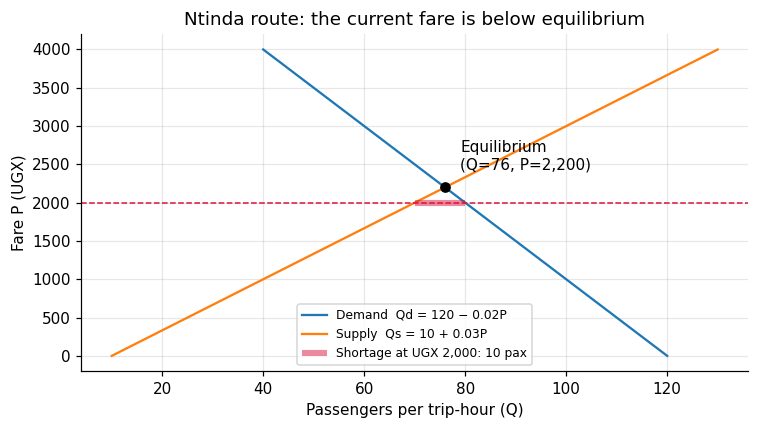

In [4]:
P = np.linspace(0, 4000, 200)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(market.quantity_demanded(P), P, label="Demand  Qd = 120 − 0.02P")
ax.plot(market.quantity_supplied(P), P, label="Supply  Qs = 10 + 0.03P")
ax.plot(Q_star, P_star, "ko")
ax.annotate(f"Equilibrium\n(Q={Q_star:.0f}, P={P_star:,.0f})", (Q_star, P_star), xytext=(10, 12), textcoords="offset points")
ax.axhline(P_now, color="crimson", ls="--", lw=1)
ax.hlines(P_now, qs, qd, color="crimson", lw=4, alpha=0.5, label=f"Shortage at UGX {P_now:,}: {qd-qs:.0f} pax")
ax.set(xlabel="Passengers per trip-hour (Q)", ylabel="Fare P (UGX)", title="Ntinda route: the current fare is below equilibrium")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**Interpretation.** The current UGX 2,000 fare is **UGX 200 below** the market-clearing fare of UGX 2,200. At UGX 2,000, 80 passengers want to travel each trip-hour but operators supply only 70 seats. The 10-passenger **shortage** shows up as queues at the stage, long waits at peak hours and pressure on conductors to charge "unofficial" peak fares. The model suggests two options: allow a modest fare increase of about 10%, or add capacity. Extra capacity shifts the supply curve right and would bring the equilibrium price down. The fare may be held below equilibrium on purpose, for affordability, since Ntinda commuters are price-sensitive. The equations are illustrative, so this is a direction, not a precise price recommendation.

## Task 3: Forecasters
All the models subclass the shared abstract `Forecaster`:
* **(a) 3-day moving average** (the original method): $\hat y_{t+1} = \tfrac13(y_t + y_{t-1} + y_{t-2})$
* **(b) Simple exponential smoothing:** $\ell_t = \alpha y_t + (1-\alpha)\ell_{t-1}$, $\hat y_{t+1} = \ell_t$. A small α means a long memory, and α = 1 means "tomorrow = today".
* **(c) Linear trend:** reused unchanged from Mini-Project 1 through inheritance.
* *(extension)* **Seasonal naïve:** $\hat y_{t+1} = y_{t+1-7}$

In [5]:
y = routes[0].passengers
for m in [MovingAverageForecaster(3), SESForecaster(0.5), LinearTrend()]:
    print(f"{m.name:<25} day-11 forecast: {m.fit(y).predict(1)[0]:.2f}")
print("Hand check MA(3):", (52 + 47 + 45) / 3)

3-day moving average      day-11 forecast: 48.00
SES (alpha=0.50)          day-11 forecast: 47.19
Linear trend              day-11 forecast: 53.67
Hand check MA(3): 48.0


## Task 4: Rolling-origin backtest (days 4–10) and α grid search
For each target day $t$ from 4 to 10, every model is fitted on days $1\ldots t-1$ only and forecasts day $t$. The window then moves forward one day. This gives 7 genuinely out-of-sample one-step forecasts per model. α is searched over the grid 0.05, 0.10, …, 1.00.

In [6]:
tuned_alpha, mae_rows, curves, backtests = {}, {}, {}, {}
for r in routes:
    bt = Backtester(r.passengers, first_day=4)
    alpha, curve = bt.tune_alpha()
    tuned_alpha[r.name], curves[r.name] = alpha, curve
    factories = {"3-day MA": lambda: MovingAverageForecaster(3),
                 "SES (α=0.5, untuned)": lambda: SESForecaster(0.5),
                 f"SES (α={alpha:.2f}, tuned)": lambda a=alpha: SESForecaster(a),
                 "Linear trend": LinearTrend}
    mae_rows[r.name] = bt.compare(factories)
    backtests[r.name] = (bt, factories)
mae_table = pd.DataFrame(mae_rows).T
mae_table.columns = [c if not c.startswith("SES (α=1") else "SES (tuned α)" for c in mae_table.columns]
display(mae_table.round(2))
print("Tuned α per route:", tuned_alpha)

,SES (tuned α),"SES (α=0.5, untuned)",3-day MA,Linear trend
Kampala-Ntinda,5.86,6.72,7.52,7.87
Kampala-Entebbe,4.43,6.04,7.19,7.71
Kampala-Mukono,3.71,4.38,5.33,6.39


Tuned α per route: {'Kampala-Ntinda': 1.0, 'Kampala-Entebbe': 1.0, 'Kampala-Mukono': 1.0}


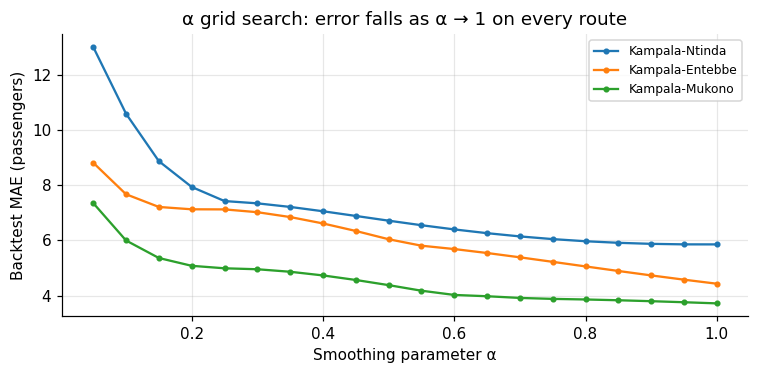

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
for name, c in curves.items():
    ax.plot(c.index, c.values, marker=".", label=name)
ax.set(xlabel="Smoothing parameter α", ylabel="Backtest MAE (passengers)", title="α grid search: error falls as α → 1 on every route")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**Result.** The tuned SES wins on every route, with MAE 3.7–5.9 passengers against 5.3–7.5 for the 3-day moving average. The grid search picks **α = 1** each time, which reduces SES to the *naïve* forecast "tomorrow = today". The reason is that the series rise until day 6 and then fall. Any model that averages over several days (a small α, the MA or the trend line) lags behind these turns, and the most recent observation is the best single guess. **Caveat:** α was tuned on the same 7 days it is scored on, so its MAE is optimistic. With only 10 days there is no separate validation window. The linear trend does worst because it keeps extrapolating the early rise after demand has already turned down.

## Task 5: Forecast day 11 revenue with the best model

In [8]:
best_rows, bt_curves = [], {}
for r in routes:
    bt, factories = backtests[r.name]
    best_name = mae_rows[r.name].index[0]
    model = factories[best_name]().fit(r.passengers)
    pax11 = float(model.predict(1)[0])
    best_rows.append({"route": r.name, "best model": best_name, "backtest MAE": mae_rows[r.name].iloc[0],
                      "day-11 pax": pax11, "day-11 revenue (UGX)": pax11 * r.fare,
                      "±1 MAE revenue range": f"{(pax11 - mae_rows[r.name].iloc[0]) * r.fare:,.0f} – {(pax11 + mae_rows[r.name].iloc[0]) * r.fare:,.0f}"})
    bt_curves[r.name] = (bt.forecasts(factories[best_name]), bt.forecasts(factories["3-day MA"]), pax11)
day11 = pd.DataFrame(best_rows).set_index("route")
day11

,best model,backtest MAE,day-11 pax,day-11 revenue (UGX),±1 MAE revenue range
route,,,,,
Kampala-Ntinda,"SES (α=1.00, tuned)",5.86,45.00,"90,000.00","78,286 – 101,714"
Kampala-Entebbe,"SES (α=1.00, tuned)",4.43,64.00,"320,000.00","297,857 – 342,143"
Kampala-Mukono,"SES (α=1.00, tuned)",3.71,50.00,"150,000.00","138,857 – 161,143"


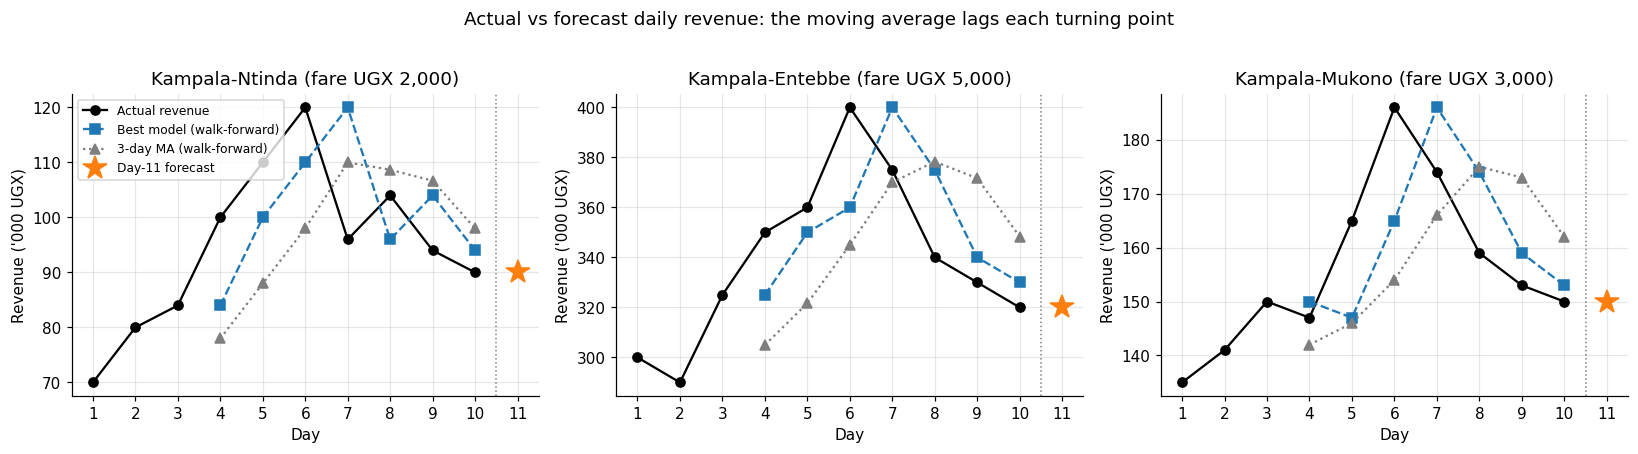

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, r in zip(axes, routes):
    best_fc, ma_fc, pax11 = bt_curves[r.name]
    ax.plot(np.arange(1, 11), r.daily_revenue() / 1000, "o-", color="black", label="Actual revenue")
    ax.plot(best_fc.index, best_fc["forecast"] * r.fare / 1000, "s--", color="tab:blue", label="Best model (walk-forward)")
    ax.plot(ma_fc.index, ma_fc["forecast"] * r.fare / 1000, "^:", color="tab:grey", label="3-day MA (walk-forward)")
    ax.plot(11, pax11 * r.fare / 1000, "*", ms=16, color="tab:orange", label="Day-11 forecast")
    ax.axvline(10.5, color="grey", ls=":", lw=1)
    ax.set(title=f"{r.name} (fare UGX {r.fare:,.0f})", xlabel="Day", ylabel="Revenue ('000 UGX)")
    ax.set_xticks(range(1, 12))
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Actual vs forecast daily revenue: the moving average lags each turning point", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "p5_revenue_forecast.png", bbox_inches="tight")
plt.show()

## Task 6: Fleet planning for day 11
Each vehicle makes 8 one-way trips a day with 14 seats, so it can carry 112 passengers a day. I add a 15% buffer and **round up**: rounding down would leave passengers stranded.

In [10]:
planner = FleetPlanner(trips_per_vehicle=8, seats=14, buffer=0.15)
fleet = day11[["day-11 pax"]].copy()
fleet["with 15% buffer"] = fleet["day-11 pax"] * 1.15
fleet["vehicles (as stated)"] = [planner.vehicles(p) for p in fleet["day-11 pax"]]
fleet["seat utilisation"] = fleet["day-11 pax"] / (fleet["vehicles (as stated)"] * planner.capacity_per_vehicle)
# Alternative reading: counts are per trip-hour (as in the Task 2 market model), 12-hour operating day
HOURS = 12
fleet["daily pax if counts are per hour (×12)"] = fleet["day-11 pax"] * HOURS
fleet["vehicles (hourly reading)"] = [planner.vehicles(p * HOURS) for p in fleet["day-11 pax"]]
# hand check Ntinda: 45*1.15/112 = 0.46 -> 1 ; 45*12*1.15/112 = 5.54 -> 6
assert fleet.loc["Kampala-Ntinda", "vehicles (as stated)"] == 1
assert fleet.loc["Kampala-Ntinda", "vehicles (hourly reading)"] == 6
fleet.round(2)

,day-11 pax,with 15% buffer,vehicles (as stated),seat utilisation,daily pax if counts are per hour (×12),vehicles (hourly reading)
route,,,,,,
Kampala-Ntinda,45.00,51.75,1,0.40,540.00,6
Kampala-Entebbe,64.00,73.60,1,0.57,768.00,8
Kampala-Mukono,50.00,57.50,1,0.45,600.00,7


**Recommendation.** If the counts are taken literally as **daily** passengers, **one vehicle per route** is enough. Each vehicle can carry 112 passengers a day and demand is only 45–64, so seat utilisation is only 40–57%. That result is suspicious. A 14-seater that makes 8 trips and carries only about 50 people a day would not cover fuel and the owner's daily target. The Task 2 market model is also expressed in passengers **per trip-hour**, with an equilibrium of 76. If the counts are hourly figures at the stage over a 12-hour day, the association needs about **6 vehicles on Ntinda, 8 on Entebbe and 7 on Mukono**. I would ask the association to confirm what the counts measure before committing vehicles. Both answers are shown so the decision is transparent.

## Extension: 60 days with a weekly pattern; seasonal naïve vs moving average
The weekly profile has Friday at +35% (paydays and people travelling upcountry) and Sunday at −40% (church and rest), with Gaussian noise (σ = 3). The backtest runs over days 15–60, so the seasonal model always has at least two full weeks of history.

,MAE
Seasonal naïve (m=7),2.98
SES (tuned α=0.05),6.88
Linear trend,7.62
3-day MA,9.46


Seasonal naïve cuts MAE by 69% versus the 3-day moving average.


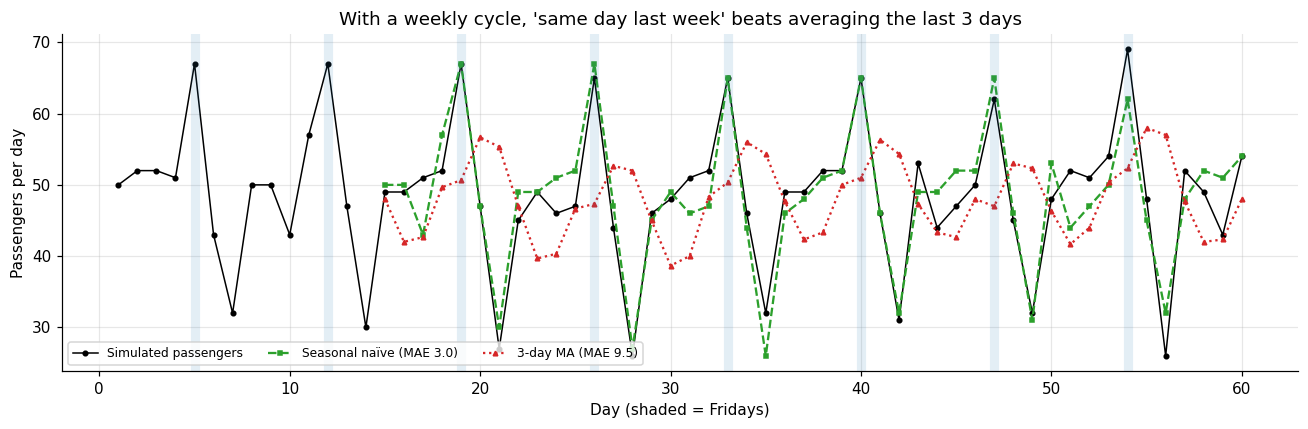

In [11]:
y60 = simulate_weekly_demand(days=60, base=50, seed=SEED, start_dow=0)
bt60 = Backtester(y60, first_day=15)
a60, _ = bt60.tune_alpha()
factories60 = {"3-day MA": lambda: MovingAverageForecaster(3),
               f"SES (tuned α={a60:.2f})": lambda: SESForecaster(a60),
               "Linear trend": LinearTrend,
               "Seasonal naïve (m=7)": lambda: SeasonalNaiveForecaster(7)}
mae60 = bt60.compare(factories60)
display(mae60.to_frame().round(2))
improvement = 1 - mae60["Seasonal naïve (m=7)"] / mae60["3-day MA"]
print(f"Seasonal naïve cuts MAE by {improvement:.0%} versus the 3-day moving average.")

fc_sn = bt60.forecasts(factories60["Seasonal naïve (m=7)"])
fc_ma = bt60.forecasts(factories60["3-day MA"])
fig, ax = plt.subplots(figsize=(12, 4))
days = np.arange(1, 61)
ax.plot(days, y60, "o-", color="black", ms=3, lw=1, label="Simulated passengers")
ax.plot(fc_sn.index, fc_sn["forecast"], "s--", color="tab:green", ms=3, label=f"Seasonal naïve (MAE {mae60['Seasonal naïve (m=7)']:.1f})")
ax.plot(fc_ma.index, fc_ma["forecast"], "^:", color="tab:red", ms=3, label=f"3-day MA (MAE {mae60['3-day MA']:.1f})")
for d in days[(np.arange(60) % 7) == 4]:
    ax.axvline(d, color="tab:blue", alpha=0.12, lw=6)
ax.set(xlabel="Day (shaded = Fridays)", ylabel="Passengers per day",
       title="With a weekly cycle, 'same day last week' beats averaging the last 3 days")
ax.legend(fontsize=8, loc="lower left", ncol=3)
fig.tight_layout()
fig.savefig(FIG_DIR / "p5_seasonal_extension.png", bbox_inches="tight")
plt.show()

The 3-day moving average is **structurally** unable to anticipate Friday: on a Friday it averages Tuesday to Thursday, which are all normal days, and on Saturday and Sunday it is still inflated by Friday. It is systematically wrong at exactly the peaks and troughs the association cares about. The seasonal naïve model carries the weekly shape forward and cuts the error by about 70%. The only error left is day-to-day noise, doubled because it compares two noisy days.

## Findings & Limitations

**Findings.** Entebbe is the association's most valuable route: it earns about UGX 340,000 a day, 3.6 times Ntinda's revenue. On Ntinda, the UGX 2,000 fare sits UGX 200 below the modelled equilibrium of UGX 2,200, which creates a shortage of about 10 passengers per trip-hour. That is a case for more vehicles at peak times or a small fare review, not for cutting service. In walk-forward testing, the original 3-day moving average was beaten on every route by exponential smoothing with α = 1, i.e. "tomorrow = today". Demand turned around mid-period, and averaging models react too slowly. The day-11 forecasts (45, 64 and 50 passengers) imply revenue of about UGX 90,000, 320,000 and 150,000. The fleet question depends on what the counts mean. Read as daily totals, one vehicle per route is enough, with idle capacity. Read as hourly stage counts, which matches the market model, 6–8 vehicles per route are needed. The extension shows that once a real weekly cycle exists, a seasonal naïve forecast cuts the error by about 70% compared with the moving average. Collect 4–6 weeks of data before relying on any model.

**Limitations.** (1) Ten observations are far too few to tune a parameter and evaluate the model honestly, so the tuned α is scored on the same data it was tuned on. (2) Revenue assumes every passenger pays the full fare. Short hops pay less in practice. (3) The supply and demand equations are hypothetical, linear and static. (4) Fleet sizing uses the average daily demand and ignores the morning and evening peaks, which drive how many vehicles are actually needed. (5) The 60-day data is synthetic with a pattern I built in, so the seasonal model's advantage is partly by construction.